# 04 · Features y modelos de pago tardío (T-07, bloques E, F y H)

**Dónde:** `pipeline/src/features/variables.py` y `pipeline/src/ml/modelos.py`. **Por qué:** anticipar qué recibos se
pagarán tarde para priorizar la cobranza. **Cómo:** variables conocidas al emitir el recibo (cada una justificada),
separación temporal (prueba = 4 últimos periodos etiquetados), CV temporal por periodo, líneas base, regresión
logística, Random Forest, Gradient Boosting y ensamble de votación en `Pipeline`; umbral elegido en CV.
**Con qué datos:** recibos etiquetados; los recibos censurados se predicen por lotes.

In [1]:
import sys, pathlib
raiz = pathlib.Path.cwd()
while not (raiz / "pipeline").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 120)
from pipeline.notebooks.graficas import dibujar, tabla

In [2]:
from pipeline.src.features.variables import JUSTIFICACION
pd.DataFrame(JUSTIFICACION.items(), columns=["variable", "justificación"])

,variable,justificación
0,tipo_tarifa,segmento de cliente; el EDA mostró tasas de atraso distintas por tarifa
1,privada,zona; captura diferencias socioeconómicas y operativas sin datos personales
2,domiciliado,H2: la asociación con el atraso es significativa (V de Cramér ≈ 0.20)
3,incluye_alcantarillado,cambia el importe (+10 %) y el tipo de servicio
4,incluye_saneamiento,cambia el importe (+12 %)
5,medidor_mudo,un recibo estimado puede generar inconformidad y retraso
6,lectura_inconsistente,misma razón: lecturas dudosas generan reclamos
7,consumo_m3,consumo del periodo facturado
8,total_pagar,monto a pagar con tarifario CEA; montos altos pueden retrasar el pago
9,antiguedad_meses,tiempo como cliente al emitir el recibo


**Modelos de pago tardío — prueba temporal (2026-04 en adelante, n=1920)**

,modelo,cv_pr_auc,umbral,pr_auc,roc_auc,f1,precision,recall,brier
0,base_mayoritaria,0.2491,0.50,0.2479,0.5000,0.0000,0.0000,0.0000,0.1865
1,base_regla_recibo_anterior,NaN,0.50,0.3208,0.6152,0.4214,0.4205,0.4223,0.2875
2,regresion_logistica,0.4482,0.48,0.4277,0.7182,0.4890,0.3835,0.6744,0.2082
3,random_forest,0.4423,0.52,0.4207,0.7209,0.4681,0.3934,0.5777,0.2057
4,gradient_boosting,0.4006,0.34,0.4252,0.7240,0.4675,0.3098,0.9517,0.2173
5,ensamble_votacion,0.4407,0.50,0.4285,0.7236,0.4981,0.3861,0.7017,0.2093


_Elegido por PR-AUC en validación cruzada temporal: regresion_logistica (PR-AUC prueba 0.428, ROC-AUC 0.718, F1 0.489) contra la regla del recibo anterior (PR-AUC 0.321, F1 0.421). Tasa real de atraso en prueba: 24.8%._  
`fuente: pipeline/src/ml/modelos.py · pipeline/notebooks/04_modelos.ipynb`

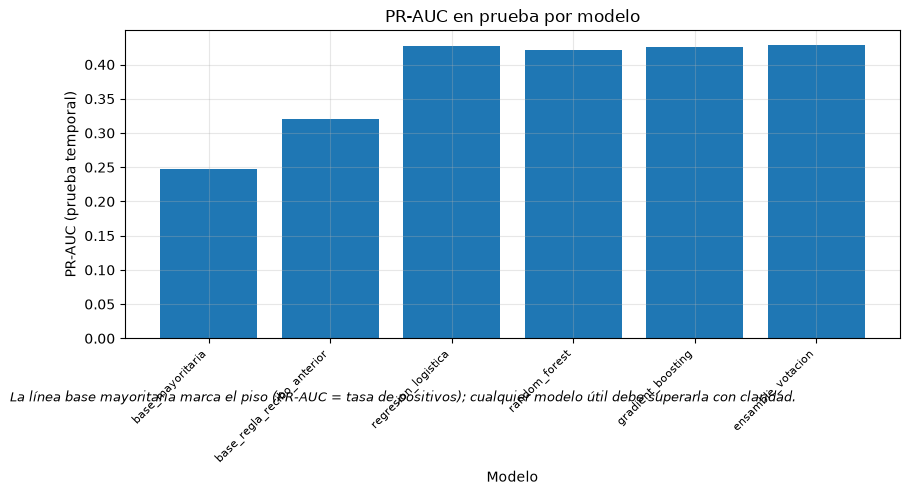

**Matriz de confusión — regresion_logistica**

,real,pred_a_tiempo,pred_tarde
0,a tiempo,928,516
1,tarde,155,321


_Detecta 321 de 476 recibos tardíos (67%) con 516 falsas alarmas; el umbral se fijó en validación cruzada para maximizar F1._  
`fuente: pipeline/src/ml/modelos.py · pipeline/notebooks/04_modelos.ipynb`

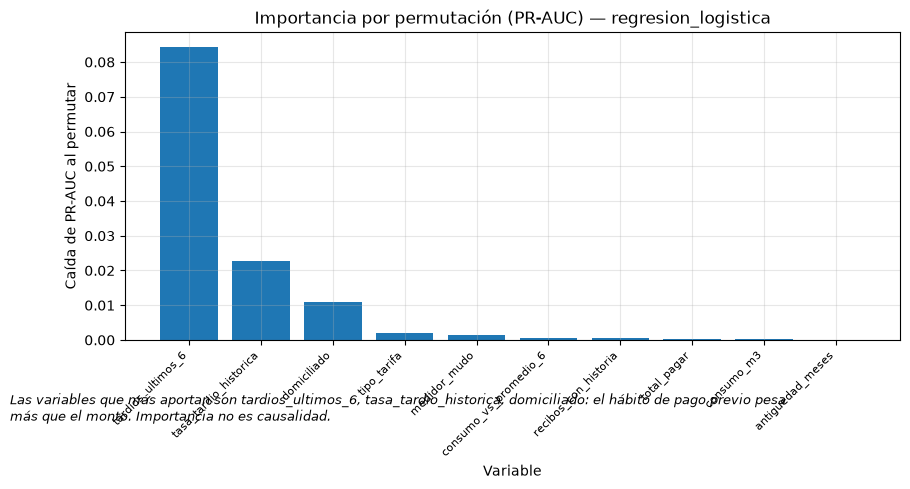

**Desempeño por tipo de tarifa (prueba)**

,tipo_tarifa,n,tasa_real,recall,precision
0,comercial,224.0,0.2902,0.7385,0.4174
1,domestico,1600.0,0.2362,0.6561,0.3741
2,industrial,36.0,0.4444,1.0000,0.4444
3,publico,60.0,0.2833,0.5294,0.3913


_Los segmentos con pocos recibos (público, industrial) tienen métricas inestables; se analizan en T-09._  
`fuente: pipeline/src/ml/modelos.py · pipeline/notebooks/04_modelos.ipynb`

**Predicción por lotes de recibos aún no vencidos**

,indicador,valor
0,recibos predichos,960
1,periodos,"2026-08, 2026-09"
2,marcados en riesgo,423
3,probabilidad media,0.4448


_423 de 960 recibos por vencer quedan marcados en riesgo de pago tardío; la lista está en analitica.predicciones_pago._  
`fuente: pipeline/src/ml/modelos.py · pipeline/notebooks/04_modelos.ipynb`

In [3]:
from pipeline.src.ml.modelos import ejecutar, payloads
res = ejecutar()
for r in payloads(res):
    dibujar(r["payload"])

In [4]:
res["predicciones"].sort_values("prob_pago_tardio", ascending=False).head(10)

,id_toma,periodo,prob_pago_tardio,clase_predicha,modelo,version
592,T95A557D58C,2026-08,0.908795,True,regresion_logistica,v1
418,T6BE1C12D07,2026-08,0.904697,True,regresion_logistica,v1
593,T95A557D58C,2026-09,0.902060,True,regresion_logistica,v1
640,TA014F1FF15,2026-08,0.885219,True,regresion_logistica,v1
419,T6BE1C12D07,2026-09,0.868628,True,regresion_logistica,v1
641,TA014F1FF15,2026-09,0.860454,True,regresion_logistica,v1
258,T486DC7662A,2026-08,0.855684,True,regresion_logistica,v1
259,T486DC7662A,2026-09,0.849201,True,regresion_logistica,v1
648,TA54FDBC969,2026-08,0.843591,True,regresion_logistica,v1
684,TB0AFAFC426,2026-08,0.834612,True,regresion_logistica,v1


## Conclusiones

In [5]:
for r in payloads(res):
    print(f"- {r['payload']['titulo']}: {r['payload']['conclusion']}")

- Modelos de pago tardío — prueba temporal (2026-04 en adelante, n=1920): Elegido por PR-AUC en validación cruzada temporal: regresion_logistica (PR-AUC prueba 0.428, ROC-AUC 0.718, F1 0.489) contra la regla del recibo anterior (PR-AUC 0.321, F1 0.421). Tasa real de atraso en prueba: 24.8%.
- PR-AUC en prueba por modelo: La línea base mayoritaria marca el piso (PR-AUC = tasa de positivos); cualquier modelo útil debe superarla con claridad.
- Matriz de confusión — regresion_logistica: Detecta 321 de 476 recibos tardíos (67%) con 516 falsas alarmas; el umbral se fijó en validación cruzada para maximizar F1.
- Importancia por permutación (PR-AUC) — regresion_logistica: Las variables que más aportan son tardios_ultimos_6, tasa_tardio_historica, domiciliado: el hábito de pago previo pesa más que el monto. Importancia no es causalidad.
- Desempeño por tipo de tarifa (prueba): Los segmentos con pocos recibos (público, industrial) tienen métricas inestables; se analizan en T-09.
- Predicción p